In [125]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
import seaborn as sns
import os
import pandas as pd
import pickle
from PcmPy.sim import make_signal
from OptimalBattery.plot import plot_correlations

# start with a G structure

In [151]:
def custom_G(n_tasks=16, n_groups=4, group_size=4, target_corr=0.0004, variance_factors=[1.0, 0.75, 0.5, 0.25]):
    G = np.zeros((n_tasks, n_tasks))
    task_index = 0

    for group in range(n_groups):
        variances = variance_factors

        # Compute covariances based on desired correlation
        covariances = target_corr * np.outer(variance_factors, variance_factors)
        np.fill_diagonal(covariances, variances)

        # Place the block into G
        start, end = task_index, task_index + group_size
        G[start:end, start:end] = covariances

        task_index += group_size

    return G

16


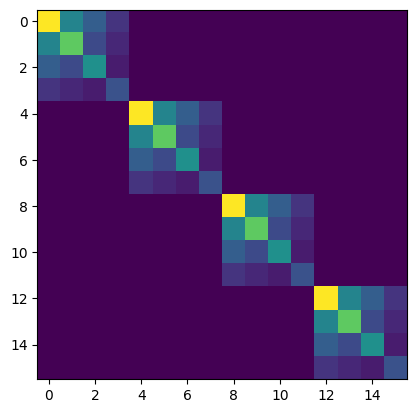

In [152]:
GL_custom = custom_G(n_tasks=16, n_groups=4, group_size=4, target_corr=0.6, variance_factors=[1.0, 0.75, 0.5, 0.25])
plt.imshow(GL_custom)

#print rank
print(np.linalg.matrix_rank(GL_custom))

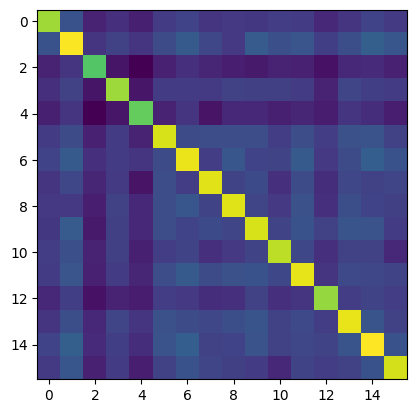

In [153]:
# random matrix shape 1000x1000
z = np.random.rand(16,1000)
GL_custom = z @ z.T
plt.imshow(GL_custom)

# Get full V using PCA and then square root of eigenvalues

In [154]:
eigenvalues, eigenvectors = np.linalg.eigh(GL_custom)

16


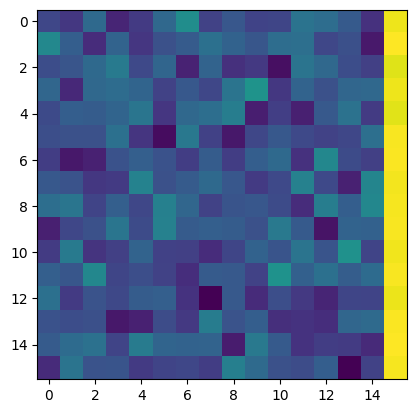

In [155]:
sqrt_eig = np.sqrt(eigenvalues)
Vlib = eigenvectors @ np.diag(sqrt_eig)
rank_v = np.linalg.matrix_rank(Vlib)

# normaliize V 
# V = V / np.sqrt(np.sum(V**2, axis=0))

plt.imshow(Vlib)
#print rank
print(np.linalg.matrix_rank(Vlib))



# Make Us random? 

In [156]:
n_parcels = 16  
n_voxels = 10000

In [157]:
U_true = np.zeros((n_parcels, n_voxels))
for i in range(n_parcels):
    U_true[i, :] = np.random.randn(n_voxels)

    # Normalize each parcel so that they have equal contribution?
    U_true[i, :] /= np.linalg.norm(U_true[i, :])

print(np.linalg.matrix_rank(U_true))

16


# Get ground truth data

In [158]:
Ylib = Vlib @ U_true
Ylib_noisy = Ylib + np.random.normal(0, 0.01, Ylib.shape)


16


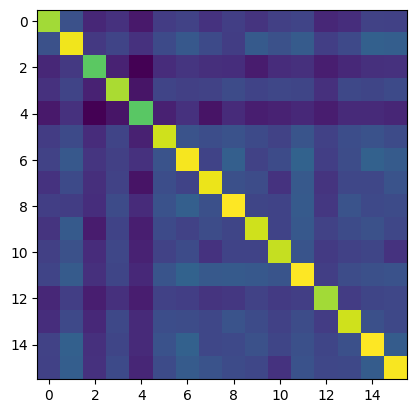

In [159]:
G_lib = Ylib_noisy @ Ylib_noisy.T
plt.imshow(G_lib)
print(np.linalg.matrix_rank(G_lib))

In [160]:
ytest = Ylib[4:8, :]
ytest_noisy = ytest+ np.random.normal(0, 0.01, ytest.shape)

vtest = Vlib[4:8, 4:6]


In [171]:
offsets = [1e-10,1e-8,1e-6,1e-4,1e-2,1,1e2,1e4,1e6,1e8,1e10]
D = ut.build_combinations(G_lib=G_lib, strategy='random',offs = offsets,n_iter=10000,n_tasks=7,seed=1)


building0


In [172]:
def evaluate_combinations(D, VLib,Ylib,U_true, ytest, vtest):
    D['combination_tuple'] = D['combination'].apply(lambda x: tuple(x))
    unique_combinations = D['combination_tuple'].unique()
    
    # Initialize a dictionary to store cos_HBP for each unique combination
    mse_ols_dict = {}
    cos_ols_dict = {}
    
    # Loop over each unique combination
    for i, comb_tuple in enumerate(unique_combinations):
        if i % 100 == 0:
            print(f"Processing combination: {i}")
        
        # Get the task subset indices and corresponding data
        task_subset_indices = list(comb_tuple)
        V_subset = VLib[task_subset_indices, 4:6]
        V_subset = V_subset - np.mean(V_subset, axis=0)

        y_subset = Ylib[task_subset_indices, :]
        y_subset = y_subset - np.mean(y_subset, axis=0)

        U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
        mse_ols = sim.U_MSE(U_true[4:6,:], U_hat_ols)
        
        U_hat_ols = pt.tensor(U_hat_ols,dtype=pt.float32)
        ytest = pt.tensor(ytest,dtype=pt.float32)
        vtest = pt.tensor(vtest,dtype=pt.float32)
        cos_ols = ev.coserr(ytest,vtest,U_hat_ols).mean().cpu().numpy()
        cos_ols = cos_ols.item()
        
        # Store the result in the dictionary
        mse_ols_dict[comb_tuple] = mse_ols
        cos_ols_dict[comb_tuple] = cos_ols
    
    # Map the computed cos_HBP values back to the DataFrame
    D['mse_ols'] = D['combination_tuple'].map(mse_ols_dict)
    D['cos_ols'] = D['combination_tuple'].map(cos_ols_dict)
    
    return D

In [173]:
D = evaluate_combinations(D, VLib=Vlib, Ylib=Ylib_noisy, U_true=U_true, ytest=ytest_noisy, vtest=vtest)

Processing combination: 0
Processing combination: 100
Processing combination: 200


C:\Users\barafat\AppData\Local\Temp\ipykernel_22900\3033840062.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest,dtype=pt.float32)
C:\Users\barafat\AppData\Local\Temp\ipykernel_22900\3033840062.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest,dtype=pt.float32)


Processing combination: 300
Processing combination: 400
Processing combination: 500
Processing combination: 600
Processing combination: 700
Processing combination: 800
Processing combination: 900
Processing combination: 1000
Processing combination: 1100
Processing combination: 1200
Processing combination: 1300
Processing combination: 1400
Processing combination: 1500
Processing combination: 1600
Processing combination: 1700
Processing combination: 1800
Processing combination: 1900
Processing combination: 2000
Processing combination: 2100
Processing combination: 2200
Processing combination: 2300
Processing combination: 2400
Processing combination: 2500
Processing combination: 2600
Processing combination: 2700
Processing combination: 2800
Processing combination: 2900
Processing combination: 3000
Processing combination: 3100
Processing combination: 3200
Processing combination: 3300
Processing combination: 3400
Processing combination: 3500
Processing combination: 3600
Processing combinatio

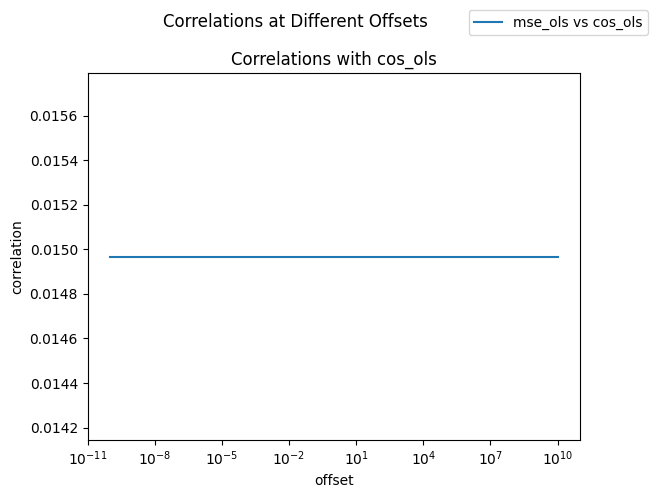

In [174]:
plot_correlations(D, ['mse_ols'],['cos_ols'])